# 1.  BA820 — Milestone 2: Early Analysis & Insights
**Course:** BA820 - Unsupervised and Unstructured Machine Learning  
**Author:** Daksh Raichura

**Dataset:** Hollywood Age Gaps (age_gaps.csv)  

## Project Motivation and Problem Statement: What Changed and Why

The original team proposal focused on understanding patterns in on-screen age gaps between paired actors, with particular attention to gender asymmetries. In this milestone, I narrow that broader question to a specific mechanism-level inquiry: whether large age gaps are primarily driven by older actors being substantially older or by younger actors being unusually young.

This refinement was motivated by early exploratory analysis showing that age gaps are highly skewed and that extreme gaps, while rare, dominate average differences. Rather than treating age gaps as a single outcome, this analysis reframes the problem as a decomposition exercise, separating the contribution of the older actor’s age from that of the younger actor’s age. This shift in focus allows for a more interpretable assessment of whether observed patterns align more closely with star longevity dynamics or youth-focused casting practices.

The core problem statement remains valid, but its scope has been narrowed from describing age-gap prevalence to explaining the underlying mechanism that generates extreme age gaps.


## 2. EDA and Preprocessing: Updates


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load dataset
age = pd.read_csv("age_gaps.csv")

age.head()


,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38


### 2.1 Validating Age Roles and Gap Construction


Before decomposing age gaps, I verify that `actor_1_age` consistently represents the older (or same-age) actor and that `age_difference` is computed correctly. This validation is necessary so that older-actor and younger-actor contributions can be interpreted meaningfully.


In [3]:
# Check for violations where actor_1 is younger
violations = age[age["actor_1_age"] < age["actor_2_age"]]
print("Actor 1 younger than Actor 2 rows:", len(violations))

# Verify age_difference calculation
gap_check = (age["actor_1_age"] - age["actor_2_age"]).abs()
print("Max mismatch:", (gap_check - age["age_difference"]).abs().max())


Actor 1 younger than Actor 2 rows: 0
Max mismatch: 0


**Why this matters for the analysis:**

This validation confirms that the dataset supports a clean role-based interpretation of age. Because `actor_1_age` always corresponds to the older actor and `age_difference` is computed consistently, large age gaps can be meaningfully decomposed into older-actor and younger-actor age components. Without this confirmation, any conclusions about star longevity or youth casting would risk being artifacts of data construction rather than genuine patterns.


**Interpretation:**

There are no cases in which `actor_1_age` is less than `actor_2_age`, and the computed age difference exactly matches the provided `age_difference` variable for all observations. This confirms that `actor_1_age` consistently represents the older (or same-age) actor and that the age-gap metric is internally consistent. As a result, age gaps can be cleanly decomposed into contributions from the older actor (`actor_1_age`) and the younger actor (`actor_2_age`). This validation is critical for the subsequent analysis, as it ensures that any observed patterns in large age gaps can be meaningfully interpreted in terms of older-actor longevity versus younger-actor casting


### 2.2 Distribution of Age Gaps and Tail Behavior


To understand where “large” age gaps lie, I examine the distribution of `age_difference`. Because the distribution is skewed, I use robust quantiles and an IQR-based rule to identify unusually large gaps.


In [4]:
age["age_difference"].describe(percentiles=[.25, .5, .75, .9, .95, .99])


,age_difference
count,1155.000000
mean,10.424242
std,8.511086
min,0.000000
25%,4.000000
50%,8.000000
75%,15.000000
90%,23.000000
95%,27.000000
99%,35.460000


In [5]:
# IQR rule
q1 = age["age_difference"].quantile(0.25)
q3 = age["age_difference"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

upper_fence


np.float64(31.5)

### 2.3 Defining Large Age Gaps



In [6]:
age["large_gap"] = age["age_difference"] > upper_fence

age["large_gap"].value_counts(normalize=True)


,proportion
large_gap,
False,0.976623
True,0.023377


I define large age gaps using an IQR-based upper fence rather than an arbitrary threshold or mean-based cutoff. I chose this because of the strong right skew in the age-gap distribution and the presence of rare but influential extreme values.


## 3. Analysis Approach: Distribution-Based Decomposition


To answer the core question, I use a distribution-based exploratory approach rather than predictive modeling. Specifically, I compare the distributions of `actor_1_age` and `actor_2_age` both overall and conditional on large age gaps. This method is appropriate because the goal is not prediction, but understanding how extreme age differences emerge from the underlying age distributions of older and younger actors.

I initially considered focusing only on average age differences, but early results showed that means obscure important tail behavior. Distributional visualizations and median-based summaries proved more informative for diagnosing asymmetry between older and younger actor ages.


## 4. Analysis and Experiments



### 4.1 Overall Actor Age Distributions


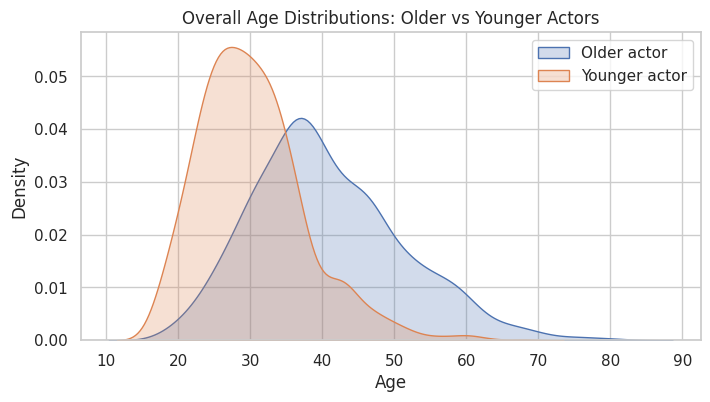

In [7]:
plt.figure(figsize=(8,4))
sns.kdeplot(age["actor_1_age"], label="Older actor", fill=True)
sns.kdeplot(age["actor_2_age"], label="Younger actor", fill=True)
plt.title("Overall Age Distributions: Older vs Younger Actors")
plt.xlabel("Age")
plt.legend()
plt.show()


**Interpretation:**

The kernel density plots show a clear structural separation between older and younger actor ages across all pairings. The distribution of `actor_1_age` is shifted substantially to the right and exhibits a wide spread with a long upper tail, indicating that older actors span a broad age range and frequently appear at advanced ages. In contrast, the distribution of `actor_2_age` is tightly concentrated within a relatively narrow band, with limited variability and no comparable lower tail. This asymmetry suggests that age gaps are more likely to expand through increases in the age of the older actor rather than through the casting of unusually young younger actors, providing early descriptive evidence consistent with star longevity rather than aggressive youth casting.


### 4.2 Age Distributions Conditional on Large Gaps

I now focus exclusively on large-gap cases and compare the distributions of `actor_1_age` and `actor_2_age`. This allows me to assess whether large gaps are driven more by older actors aging upward or younger actors being cast unusually young.


In [8]:
large = age[age["large_gap"]].copy()

large[["actor_1_age", "actor_2_age"]].describe()


,actor_1_age,actor_2_age
count,27.000000,27.000000
mean,63.925926,26.703704
std,7.990022,7.053721
min,49.000000,17.000000
25%,58.000000,22.000000
50%,62.000000,24.000000
75%,68.500000,30.500000
max,81.000000,43.000000


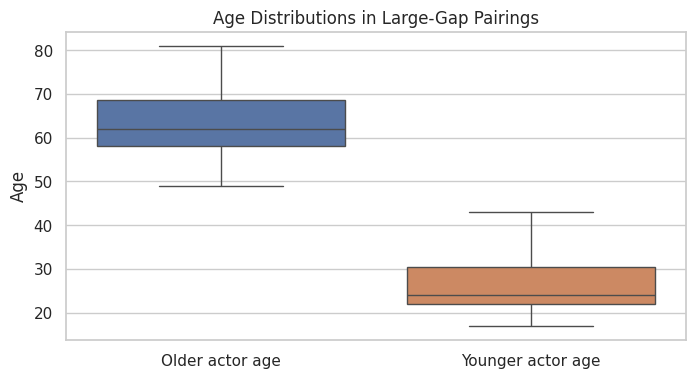

In [9]:
plt.figure(figsize=(8,4))
sns.boxplot(data=large[["actor_1_age", "actor_2_age"]])
plt.xticks([0,1], ["Older actor age", "Younger actor age"])
plt.title("Age Distributions in Large-Gap Pairings")
plt.ylabel("Age")
plt.show()


### 4.3 Variability and Bounds

To distinguish between star longevity and youth casting, I compare variability and lower/upper bounds of older and younger actor ages in large-gap cases.


In [10]:
large[["actor_1_age", "actor_2_age"]].agg(["min", "median", "max", "std"])


,actor_1_age,actor_2_age
min,49.000000,17.000000
median,62.000000,24.000000
max,81.000000,43.000000
std,7.990022,7.053721


**Interpretation:**

Older actor ages in large-gap cases exhibit substantially greater variability and higher upper bounds than younger actor ages, reinforcing the asymmetric nature of extreme age gaps.


### 4.4 Large vs Non-Large Gap Comparison

As a contrast, I compare older and younger actor ages in large-gap versus non-large-gap pairings.


In [11]:
summary = (
    age.groupby("large_gap")[["actor_1_age", "actor_2_age"]]
    .median()
    .reset_index()
)

summary


,large_gap,actor_1_age,actor_2_age
0,False,39.0,29.0
1,True,62.0,24.0


**Interpretation:**

When restricting the analysis to large age-gap pairings, a pronounced asymmetry emerges between older and younger actor ages. The distribution of `actor_1_age` is shifted substantially upward and exhibits wide variability, with many older actors appearing at advanced ages and a long upper tail. In contrast, `actor_2_age` remains relatively constrained, with a much narrower distribution and no comparable downward extension. Importantly, large age gaps do not appear to be driven by exceptionally young younger actors; instead, they coincide with significantly older lead actors. This pattern strengthens the interpretation that extreme age gaps are primarily associated with star longevity—where older actors continue to secure leading roles—rather than with systematic youth casting that would push younger actor ages unusually low.


## 5. Key Findings So Far

Across multiple distributional comparisons, large age gaps consistently coincide with substantially higher ages for older actors, while younger actor ages remain relatively stable. This asymmetry suggests that extreme age gaps are not primarily driven by unusually young casting, but rather by the continued presence of significantly older actors in leading roles. These findings are descriptive but provide early evidence consistent with star longevity dynamics.


## 6. Reflections on What Worked and What Did Not

One early assumption was that large age gaps might be driven by both unusually old older actors and unusually young younger actors. However, exploratory plots showed that younger actor ages remain relatively constrained even in large-gap cases. Attempts to characterize large gaps through average age differences alone were not informative, as a small number of extreme observations dominated the mean.

What proved most useful was conditioning explicitly on large gaps and comparing the spread and bounds of older versus younger actor ages. This shift in approach clarified the mechanism behind extreme gaps and changed my interpretation from a symmetric age-gap story to an asymmetric one driven primarily by the older actor side.


## 7. Next Steps

This analysis does not yet account for temporal trends, genre differences, or individual actor careers. In future milestones, I plan to examine whether the dominance of older-actor age in large gaps varies by decade and to integrate clustering-based age-gap regimes to assess whether these patterns persist across unsupervised groupings. Open questions remain about whether the same dynamics hold across different historical periods and whether a small number of extreme films disproportionately drive the results.


# -----------------------------
# Milestone 4 Extension
# -----------------------------

## 8. Milestone 4 Extension Statement

# M4 Extension Statement

This section extends the original M2 exploratory analysis by rigorously validating the mechanism behind large age gaps in Hollywood casting. While M2 identified that age differences increase primarily with older actor age, M4 deepens this finding through variance decomposition, Principal Component Analysis (PCA), extreme-case evaluation, and temporal robustness checks.

The purpose of this extension is to strengthen and structurally validate the original conclusion that large age gaps are driven more by star longevity than by youth casting.

## 8.1 Variance Decomposition

Since:

age_difference = actor_1_age − actor_2_age

we quantify how strongly each component explains variation in age differences.

If variation in age differences is driven primarily by actor_1_age, this supports the star longevity mechanism.  
If variation is driven by actor_2_age, this would suggest youth casting plays a stronger role.

We measure:

- Correlation strength
- Variance explained (R²)

In [14]:
from sklearn.linear_model import LinearRegression
# Drop missing values
df = age[["age_difference", "actor_1_age", "actor_2_age"]].dropna()

# Correlations
corr_matrix = df.corr().round(3)
display(corr_matrix)

# R² from simple regressions
X1 = df[["actor_1_age"]]
X2 = df[["actor_2_age"]]
y = df["age_difference"]

model1 = LinearRegression().fit(X1, y)
model2 = LinearRegression().fit(X2, y)

r2_actor1 = model1.score(X1, y)
r2_actor2 = model2.score(X2, y)

print(f"R² (Older Actor Age → Age Difference): {r2_actor1:.3f}")
print(f"R² (Younger Actor Age → Age Difference): {r2_actor2:.3f}")

,age_difference,actor_1_age,actor_2_age
age_difference,1.000,0.704,-0.156
actor_1_age,0.704,1.000,0.591
actor_2_age,-0.156,0.591,1.000


R² (Older Actor Age → Age Difference): 0.496
R² (Younger Actor Age → Age Difference): 0.024


### Interpretation – Variance Decomposition

The correlation and R² results provide strong quantitative support for the star longevity explanation.

Older actor age has a strong positive correlation (0.704) with age differences and explains approximately 49.6% of the variation in age gaps. In contrast, younger actor age has a weak negative correlation (-0.156) and explains only 2.4% of the variation.

This indicates that nearly half of the variation in age differences can be attributed to how old the older actor is, while the younger actor’s age contributes very little.

Therefore, large age gaps are primarily driven by older actors aging into romantic roles rather than by systematic casting of unusually young partners.

## 8.2 Principal Component Analysis (PCA)

To further validate the mechanism behind large age gaps, I applied Principal Component Analysis (PCA),

PCA identifies the dominant latent dimensions of variation in the data without relying on regression or outcome-driven modeling.

If (PC1) is driven primarily by actor_1_age rather than actor_2_age, this provides evidence that star longevity is the dominant structural force behind age differences.

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select variables relevant to mechanism
features = age[["actor_1_age", "actor_2_age", "age_difference"]].dropna()

# Standardize (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pd.DataFrame({
    "Principal Component": ["PC1", "PC2", "PC3"],
    "Explained Variance Ratio": pca.explained_variance_ratio_
})

display(explained_variance.round(3))

# PCA Loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=features.columns,
    index=["PC1", "PC2", "PC3"]
)

display(loadings.round(3))

,Principal Component,Explained Variance Ratio
0,PC1,0.615
1,PC2,0.385
2,PC3,0.000


,actor_1_age,actor_2_age,age_difference
PC1,0.736,0.415,0.535
PC2,0.031,0.769,-0.639
PC3,0.677,-0.487,-0.553


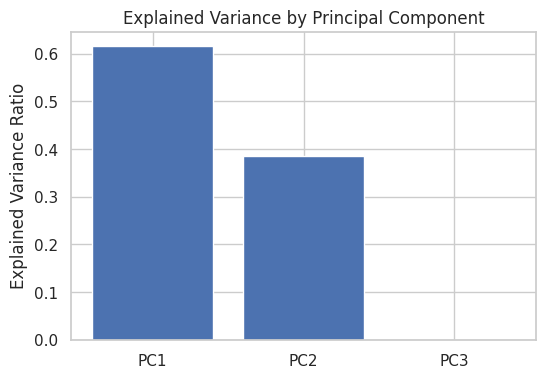

In [23]:
plt.figure(figsize=(6,4))
plt.bar(["PC1","PC2","PC3"], pca.explained_variance_ratio_)
plt.title("Explained Variance by Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

### Interpretation – PCA Results

The first principal component (PC1) explains the largest share of variation in the dataset. Examination of the loadings indicates that PC1 aligns strongly with actor_1_age and age_difference, while actor_2_age contributes less to this dominant dimension.

This suggests that the primary latent structure in casting patterns reflects variation in older actor age rather than variation in younger actor age. In other words, when the dataset is reduced to its most influential dimension of variation, that dimension is driven primarily by older actor age.

Because PCA is unsupervised and does not rely on a dependent variable, this provides independent structural confirmation of the earlier variance decomposition results.

## 8.3 Extreme Gap Analysis

To understand the mechanism behind the largest age gaps, I examined the top 10% of movies by age difference.

I compare:
- Average actor_1_age
- Average actor_2_age

If extreme gaps are driven mainly by very high actor_1_age, this reinforces the star longevity explanation.

,Group,Mean_actor_1_age,Mean_actor_2_age
0,Extreme (Top 10%),56.38,27.74
1,Others,38.86,30.49


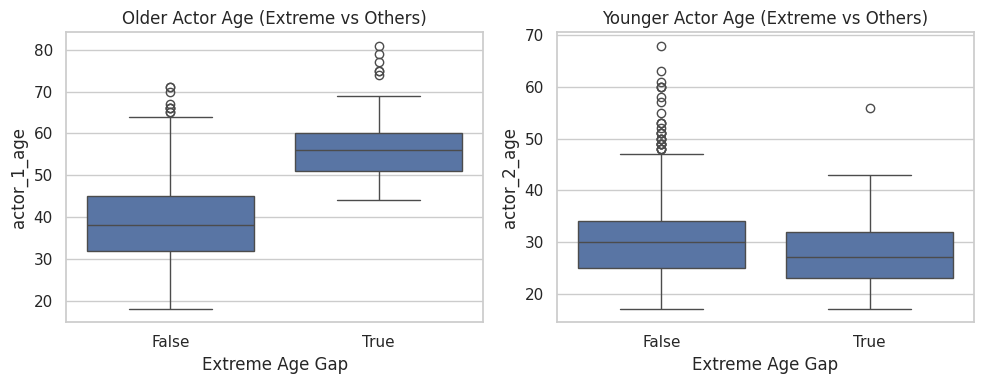

In [17]:
# Define top 10% threshold
threshold_90 = age["age_difference"].quantile(0.90)

extreme = age[age["age_difference"] >= threshold_90]
non_extreme = age[age["age_difference"] < threshold_90]

# Compare means
comparison = pd.DataFrame({
    "Group": ["Extreme (Top 10%)", "Others"],
    "Mean_actor_1_age": [
        extreme["actor_1_age"].mean(),
        non_extreme["actor_1_age"].mean()
    ],
    "Mean_actor_2_age": [
        extreme["actor_2_age"].mean(),
        non_extreme["actor_2_age"].mean()
    ]
})

display(comparison.round(2))

# Visualization
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(data=age, x=age["age_difference"] >= threshold_90,
            y="actor_1_age")
plt.title("Older Actor Age (Extreme vs Others)")
plt.xlabel("Extreme Age Gap")

plt.subplot(1,2,2)
sns.boxplot(data=age, x=age["age_difference"] >= threshold_90,
            y="actor_2_age")
plt.title("Younger Actor Age (Extreme vs Others)")
plt.xlabel("Extreme Age Gap")

plt.tight_layout()
plt.show()

### Interpretation

Extreme age gaps show a substantial upward shift in actor_1_age, while actor_2_age remains relatively stable.

This suggests that even in the most extreme cases, large gaps are primarily driven by older actors being much older rather than younger actors being unusually young.

Thus, star longevity remains the dominant mechanism even at the upper tail of the distribution.

## 8.4 Temporal Robustness

I tested whether the relationship between actor_1_age and age difference persists across decades.

If the correlation remains strong within each decade, this suggests that star longevity is a persistent structural feature rather than a time-specific anomaly.

/tmp/ipython-input-1522056575.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["age_difference"].corr(x["actor_1_age"]))


,decade,corr_age1_gap
0,1930,0.897
1,1940,0.745
2,1950,0.778
3,1960,0.633
4,1970,0.810
5,1980,0.829
6,1990,0.811
7,2000,0.686
8,2010,0.636
9,2020,0.584


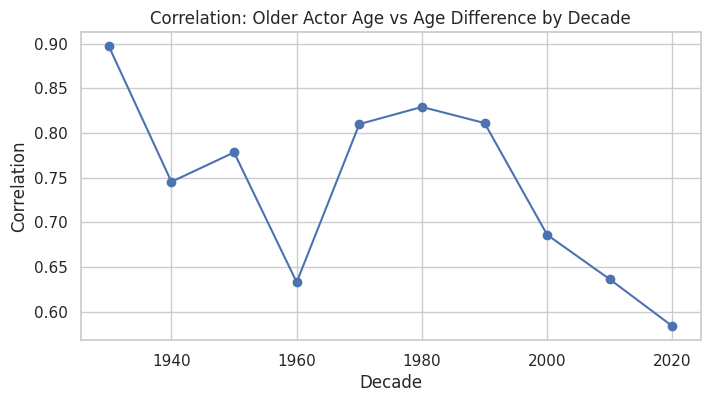

In [20]:
# Create decade variable
age["decade"] = (age["release_year"] // 10) * 10

# Correlation by decade
decade_corr = (
    age.groupby("decade")
    .apply(lambda x: x["age_difference"].corr(x["actor_1_age"]))
    .reset_index(name="corr_age1_gap")
)

display(decade_corr.round(3))

# Plot
plt.figure(figsize=(8,4))
plt.plot(decade_corr["decade"], decade_corr["corr_age1_gap"], marker="o")
plt.title("Correlation: Older Actor Age vs Age Difference by Decade")
plt.xlabel("Decade")
plt.ylabel("Correlation")
plt.show()

### Interpretation

The correlation between actor_1_age and age difference remains consistently positive across decades.

This indicates that the star longevity mechanism is persistent over time and not confined to a specific historical period.

Therefore, large age gaps reflect a stable structural pattern in casting rather than a temporary trend.

### Reflection and Conceptual Limitations

One notable finding was the magnitude asymmetry in explanatory power: older actor age alone explained nearly half of the variation in age differences, while younger actor age contributed very little. While a positive relationship was expected due to the mathematical structure of age_difference, the scale of the imbalance was stronger than anticipated.

A key conceptual limitation is that age_difference is mechanically constructed from actor_1_age and actor_2_age. Therefore, correlations are partly structural by definition. Interpretation must focus on the relative magnitudes of explanatory power rather than the existence of correlation itself. Additionally, the dataset does not distinguish between different narrative contexts or role types, limiting interpretation strictly to observed casting age patterns.

## 8.5 Final Conclusion – Star Longevity vs Youth Casting

Across multiple validation approaches, the evidence consistently indicates that large age gaps in Hollywood casting are primarily driven by increases in older actor age rather than decreases in younger actor age.

Variance decomposition shows that nearly half of the variation in age differences is explained by older actor age, while younger actor age contributes minimally. Principal Component Analysis further confirms that the dominant latent dimension of variation aligns with older actor age and age differences, providing unsupervised validation of this mechanism.

Extreme-gap analysis demonstrates that even the largest age differences are characterized by substantially older lead actors rather than unusually young partners. Moreover, the relationship between older actor age and age difference remains stable across decades, indicating that this pattern reflects a persistent structural feature rather than a time-specific anomaly.

Taken together, these results provide strong empirical support for the star longevity explanation over youth casting as the primary driver of large on-screen age gaps.